Name: Gaurav Santosh Mane
RollNo: 13253

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [6]:
df=pd.read_csv("Social_Network_Ads.csv")

In [7]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   User ID          400 non-null    int64  
 1   Gender           400 non-null    object 
 2   Age              400 non-null    float64
 3   EstimatedSalary  400 non-null    float64
 4   Purchased        400 non-null    int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 15.8+ KB


In [8]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19.0,19000.0,0
1,15810944,Male,35.0,20000.0,0
2,15668575,Female,26.0,43000.0,0
3,15603246,Female,27.0,57000.0,0
4,15804002,Male,19.0,76000.0,0
...,...,...,...,...,...
395,15691863,Female,46.0,41000.0,1
396,15706071,Male,51.0,23000.0,1
397,15654296,Female,50.0,20000.0,1
398,15755018,Male,36.0,33000.0,0


In [9]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [10]:
df['Purchased']

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 400, dtype: int64

In [11]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

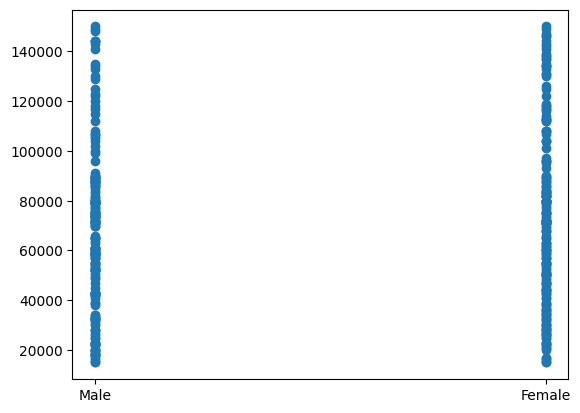

In [12]:
plt.scatter(df['Gender'],df['EstimatedSalary'])
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Gender']=le.fit_transform(df['Gender'])

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [15]:
df.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [16]:
x=df[['Gender', 'Age', 'EstimatedSalary']]
y=df[ 'Purchased']

In [17]:
x_train,x_test,y_train,y_test =train_test_split(x,y,test_size=0.2,random_state=0)

In [30]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
xtrain = sc.fit_transform(x_train)
xtest = sc.transform(x_test)


In [32]:
from sklearn.linear_model import LogisticRegression
# instantiate the model (using the default parameters)
logreg = LogisticRegression(max_iter=400)
logreg.fit(x_train, y_train)




LogisticRegression(max_iter=400)

In [33]:
y_pred = logreg.predict(x_test)

print(y_pred)

[0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0
 0 0 1 0 1 1]


In [39]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[56  2]
 [ 4 18]]


In [40]:
print(f"accuracy={accuracy_score(y_test,y_pred)}")

accuracy=0.925


In [41]:
df.groupby('Gender')['Purchased'].sum()

Gender
0    77
1    66
Name: Purchased, dtype: int64

In [43]:
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.9


In [45]:
recall = recall_score(y_test, y_pred)
print("Recall:", recall)


Recall: 0.8181818181818182


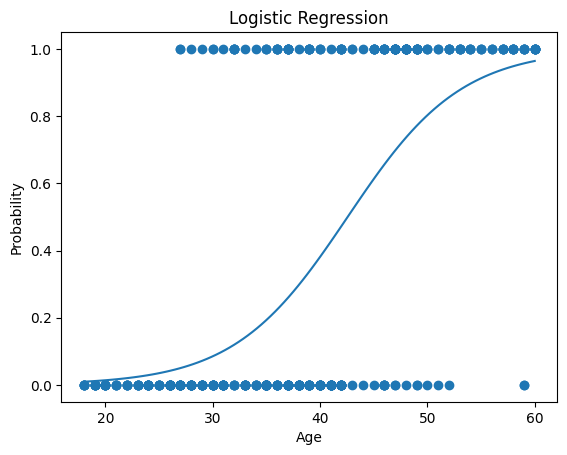

In [46]:
X = df[['Age']].values
y = df['Purchased'].values
model = LogisticRegression()
model.fit(X, y)
X_test = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
y_prob = model.predict_proba(X_test)[:,1]
plt.scatter(X, y)
plt.plot(X_test, y_prob)
plt.xlabel("Age")
plt.ylabel("Probability")
plt.title("Logistic Regression")
plt.show()


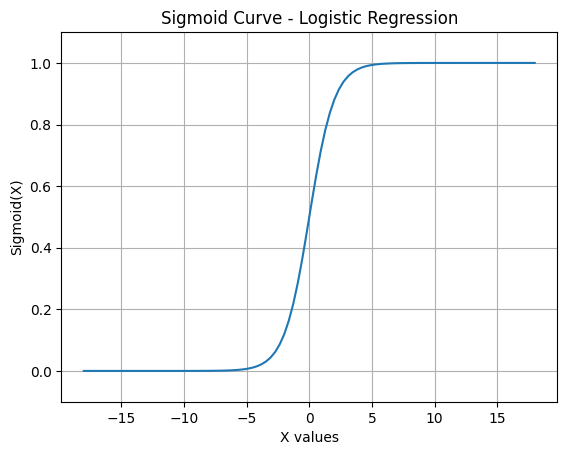

In [47]:
x = np.linspace(-18, 18, 100)
y = 1 / (1 + np.exp(-x))
plt.figure()
plt.plot(x, y)
plt.title("Sigmoid Curve - Logistic Regression")
plt.xlabel("X values")
plt.ylabel("Sigmoid(X)")
plt.ylim(-0.1, 1.1)
plt.grid()
plt.show()

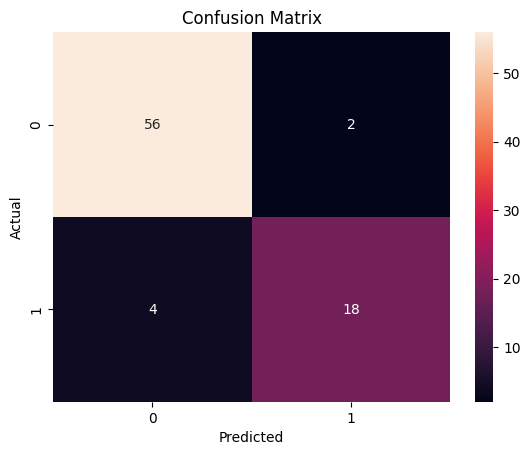

In [48]:
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
